# Grating direction/orientation selectivity (DS/OS) demo

Check the printed `epoch_parameters` keys in the cell below before trusting anything downstream -- confirms this protocol's actual parameter names for your database.

DSI/OSI use the standard vector-sum (circular statistics) definition -- see
`ra.compute_dsi_osi` docstring. Flag it if your lab uses a different convention.


In [ ]:
import retinanalysis as ra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Find GratingDSOS datasets

Searches only for `manookinlab.protocols.GratingDSOS` (exact match -- the protocol name confirmed from an earlier real search, see below). This is deliberately narrow, not the broad `'grating'` substring search this cell used to run -- it means `grating_search` only ever contains rows you actually want for this notebook, and the "choose an experiment" cell below can auto-pick a datafile_name for you from it without any risk of accidentally grabbing a ContrastResponseGrating or GratingMTF run instead.

In [2]:
grating_search = ra.get_datasets_from_protocol_names(
    'manookinlab.protocols.GratingDSOS', b_exact_match=True
)
ra.scrollable_dataframe(grating_search)


[2026-07-29 16:15:17] DataJoint 2.2.2 connected to root@127.0.0.1:3306

Found 15 experiments, 18 epoch blocks.



,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20240820A,data001,NaN,data001,manookinlab.protocols.GratingDSOS,1,20240820A\data001,gratings,212,2,742,2211,1733
1,20250423A,data001,NaN,data001,manookinlab.protocols.GratingDSOS,1,20250423A\data001,NDF 3,218,2,764,2246,1770
2,20250423A,data002,NaN,data002,manookinlab.protocols.GratingDSOS,1,20250423A\data002,NDF 2,218,2,765,2247,1771
3,20250910A,data003,4.0,data003,manookinlab.protocols.GratingDSOS,1,20250910A\data003,Control,220,2,769,2257,1781
4,20250912A,data006,3.0,data006,manookinlab.protocols.GratingDSOS,1,20250912A\data006,Control,221,2,771,2270,1792
5,20250912A,data007,3.0,data007,manookinlab.protocols.GratingDSOS,1,20250912A\data007,Control,221,2,771,2271,1793
6,20250918A,data025,0.0,data025,manookinlab.protocols.GratingDSOS,1,20250918A\data025,Control,222,2,772,2299,1822
7,20251009A,data019,0.0,data019,manookinlab.protocols.GratingDSOS,1,20251009A\data019,NDF 0,228,2,783,2341,1868
8,20251015A,data020,0.0,data020,manookinlab.protocols.GratingDSOS,1,20251015A\data020,NDF 0,230,2,789,2362,1913
9,20251015A,data022,0.0,data022,manookinlab.protocols.GratingDSOS,1,20251015A\data022,NDF 0,230,2,789,2364,1915


## Choose an experiment

Only `exp_name` needs to be set below -- `datafile_name` is auto-detected from `grating_search` above via `ra.find_datafile_for_protocol()`. If an experiment has more than one GratingDSOS run, the earliest one is used and every candidate is printed so you can tell if you'd rather use a different one -- set `MANUAL_DATAFILE_NAME` below to override.

`analysis_chunk_name` is auto-detected the same way (via `ra.find_classified_noise_chunk`) -- `MANUAL_ANALYSIS_CHUNK` overrides that independently of `MANUAL_DATAFILE_NAME`.

The cell below also prints the raw `epoch_parameters` keys for your first matching epoch so you can check before trusting anything downstream.


In [5]:
exp_name = '20260227A'
ds_os_protocol_name = 'manookinlab.protocols.GratingDSOS'  # confirmed exact string from grating_search above

MANUAL_DATAFILE_NAME = None  # e.g. 'data018' -- set this to skip auto-detection and use a specific datafile
MANUAL_ANALYSIS_CHUNK = None  # e.g. 'chunk13' -- set this to skip auto-detection and use a specific chunk

datafile_name = MANUAL_DATAFILE_NAME or ra.find_datafile_for_protocol(
    grating_search, exp_name, protocol_name=ds_os_protocol_name
)
if datafile_name is None:
    raise ValueError(
        f'No {ds_os_protocol_name} datafile found for {exp_name} in grating_search -- '
        'pick a different exp_name from the table above, or set MANUAL_DATAFILE_NAME.'
    )

analysis_chunk_name = MANUAL_ANALYSIS_CHUNK or ra.find_classified_noise_chunk(exp_name)
if analysis_chunk_name is None:
    print(
        'No classified NDF0/NDF1 white-noise chunk found -- falling back to '
        'create_mea_pipeline\'s own nearest-chunk logic. This may crash if that '
        'chunk lacks a classification file or has an incomplete .globals file; if '
        'so, set MANUAL_ANALYSIS_CHUNK above to a chunk you know is classified.'
    )

pipeline = ra.create_mea_pipeline(exp_name, datafile_name, analysis_chunk_name=analysis_chunk_name)
stim_block = pipeline.stim
response_block = pipeline.resp

df_epochs = stim_block.df_epochs
print(f'{len(df_epochs)} epochs found for {exp_name} {datafile_name}')
print('protocol_name(s) present:', df_epochs['protocol_name'].unique())
print()
print('epoch_parameters keys for epoch 0 (VERIFY these match what the code below assumes):')
print(sorted(df_epochs.at[0, 'epoch_parameters'].keys()))
print()
print('epoch 0 orientation/spatialFrequency/temporalFrequency/barWidth:')
for key in ['orientation', 'spatialFrequency', 'temporalFrequency', 'barWidth']:
    print(f'  {key}:', df_epochs.at[0, 'epoch_parameters'].get(key, '<<< NOT FOUND, code below will break >>>'))


20260227A: using datafile data012.
20260227A: NDF 0 has 1 white-noise chunk(s) (['data011']), but none have a classification file.
20260227A: NDF 0 had no classified chunk, falling back to NDF 1.
20260227A: using data009 (NDF 1, classification file(s): ['KSclassification.txt']).
  Stimulus parameters for data009:
    NDF: 1.0
    alpha: 1.0
    amp: Amp1
    amp2: (None)
    appVersion: None
    backgroundIntensity: 0.5
    canvasSize: [1824.0, 1140.0]
    centerOffset: [0.0, 0.0]
    chromaticClass: achromatic
    contrast: 1.0
    dataFileName: 20260227A\data009.bin
    dspVersion: None
    expectedRefreshRate: 59.94
    externalCommandSensitivity: 0.02
    externalCommandSensitivityUnits: V_V
    filterSdStixels: 1.0
    firmwareVersion: None
    frameDwell: 2.0
    frameDwells: [2.0, 2.0]
    frameRate: 59.0
    gaussianFilter: 0
    gridSize: 100.0
    hardwareType: MCTG_HW_TYPE_MC700B
    interpulseInterval: 0.5
    lightCrafterLedCurrents: [104.0, 135.0, 130.0]
    lightCrafterL

## Bin spikes and extract F1 per (cell, trial)

`bin_spike_times_at_rate` is protocol-agnostic (unlike the frame-based binning demo 2 uses, which needs stimulus regen) -- it just needs epoch start/end timing, which should exist for any protocol. `b_count=False` gives a rate in Hz, which is what `compute_f1_f0` expects.

100 Hz bins (10ms) give plenty of margin above the ~2-4 Hz temporal frequencies seen in this stimulus -- raise BIN_RATE if your temporalFrequency values are much higher.

In [6]:
BIN_RATE = 100.0  # Hz
response_block.bin_spike_times_at_rate(bin_rate=BIN_RATE, b_count=False)

cell_ids = response_block.cell_ids
n_cells = len(cell_ids)
n_epochs = response_block.n_epochs
print(f'{n_cells} cells x {n_epochs} epochs, binned_spikes shape: {response_block.binned_spikes.shape}')


Binning spikes for cells:   0%|          | 0/671 [00:00<?, ?it/s]

671 cells x 240 epochs, binned_spikes shape: (671, 240, 550)


## Build a tidy per-(cell, trial) dataframe: mean rate + both F1 methods

Two independent things get computed here, on purpose:

1. **`mean_rate`** -- spike count in the stimulus window divided by `stimTime`. This
   (not F1) is what feeds DSI/OSI below, matching the lab's existing `DS-OS.ipynb` convention.
2. **F1, two ways, side by side for comparison**:
   - `f1_binned` / `f0_binned` -- via `ra.compute_f1_f0` on the binned rate trace
     from the cell above. Simple, and the same binned-rate array is reusable for
     PSTHs/rasters elsewhere, but has small binning error (10ms bins here).
   - `f1_spiketime` / `f0_spiketime` -- via `ra.compute_f1_f0_from_spikes` directly
     on raw spike times (no binning). Exact, and matches the vector-sum method the lab's existing MATLAB code uses (`phases = 2*pi*f*t; f1 = 2*|sum(exp(i*phases))|/duration`),
     but needs raw spike times rather than a pre-binned array.

   The two agree closely. This notebook doesn't use either F1 column for DSI/OSI --
   they're here for comparison/QC and for later contrast-response work, where F1
   (not mean rate) is usually the standard metric.

Raw spike times come from `response_block.df_spike_times` (one row per cell, a list
of per-epoch spike-time arrays in ms, already relative to trial/epoch start -- see
`ResponseBlock.get_spike_times()`). They're pulled out into `spike_times_by_cell`
here so the raster plots later in the notebook can reuse them without recomputing.


In [7]:
spike_times_by_cell = response_block.df_spike_times.set_index('cell_id')['spike_times']

rows = []
for j_epoch in range(n_epochs):
    row = df_epochs.iloc[j_epoch]
    if row['protocol_name'] != ds_os_protocol_name:
        continue

    params = row['epoch_parameters']
    pre_time_s = row['preTime'] / 1000.0
    stim_time_s = row['stimTime'] / 1000.0
    pre_bin = int(round(pre_time_s * BIN_RATE))
    stim_bins = int(round(stim_time_s * BIN_RATE))
    stim_freq = params['temporalFrequency']

    for i_cell, cell_id in enumerate(cell_ids):
        # --- Method 1: binned-FFT F1 ---
        full_rate = response_block.binned_spikes[i_cell, j_epoch, :]
        stim_rate = full_rate[pre_bin : pre_bin + stim_bins]
        f0_binned, f1_binned = ra.compute_f1_f0(stim_rate, BIN_RATE, stim_freq)

        # --- Method 2: direct spike-time F1, and mean_rate (input to DSI/OSI below) ---
        trial_spikes_ms = spike_times_by_cell.loc[cell_id][j_epoch]
        trial_spikes_s = (
            np.asarray(trial_spikes_ms) / 1000.0
            if trial_spikes_ms is not None and len(trial_spikes_ms) > 0
            else np.array([])
        )
        # keep only spikes inside the stimulus window, shifted so t=0 is stim onset
        in_window = (trial_spikes_s >= pre_time_s) & (trial_spikes_s < pre_time_s + stim_time_s)
        stim_spikes_s = trial_spikes_s[in_window] - pre_time_s

        mean_rate = len(stim_spikes_s) / stim_time_s if stim_time_s > 0 else 0.0
        f0_spiketime, f1_spiketime = ra.compute_f1_f0_from_spikes(stim_spikes_s, stim_freq, stim_time_s)

        rows.append({
            'cell_id': cell_id,
            'epoch_index': j_epoch,
            'orientation': params['orientation'],
            'spatialFrequency': params['spatialFrequency'],
            'temporalFrequency': stim_freq,
            'barWidth': params.get('barWidth'),
            'mean_rate': mean_rate,
            'f1_binned': f1_binned,
            'f0_binned': f0_binned,
            'f1_spiketime': f1_spiketime,
            'f0_spiketime': f0_spiketime,
        })

df_trials = pd.DataFrame(rows)
print(f'{len(df_trials)} (cell, trial) rows')
display(df_trials.head())


161040 (cell, trial) rows


,cell_id,epoch_index,orientation,spatialFrequency,temporalFrequency,barWidth,mean_rate,f1_binned,f0_binned,f1_spiketime,f0_spiketime
0,1,0,210.0,0.011628,4.0,100.0,26.6,10.258201,26.6,10.251030,26.6
1,2,0,210.0,0.011628,4.0,100.0,0.4,0.247214,0.4,0.199925,0.4
2,3,0,210.0,0.011628,4.0,100.0,12.2,4.505518,12.2,4.498586,12.2
3,4,0,210.0,0.011628,4.0,100.0,18.2,11.452506,18.2,11.211469,18.2
4,5,0,210.0,0.011628,4.0,100.0,2.4,0.813692,2.4,0.780853,2.4


## DSI/OSI per cell, following the lab's existing `DS-OS.ipynb` convention exactly

Differences from a "generic" vector-sum approach (deliberate, matching the existing
lab notebook rather than inventing a new convention):

- **Input is `mean_rate`, not F1.** DSI/OSI go into `ra.compute_dsi_osi` computed
  from mean firing rate per orientation, averaged across repeats.
- **One (spatialFrequency, temporalFrequency) condition per cell**, chosen as
  whichever condition gives that cell's highest peak mean rate across orientations
  -- not one DSI/OSI per condition like the previous version of this notebook did.
  This matches the population loop in the lab's existing `DS-OS.ipynb`.
- **Thresholds, from the lab's existing `DS-OS.ipynb`:** `DSI_THRESHOLD = 0.3`, `OSI_THRESHOLD = 0.3`,
  `MIN_RESPONSE_HZ = 2.0` (peak rate must clear this or the cell isn't counted as
  DS or OS at all, regardless of index value).
- **`ds_cells` and `os_cells` are mutually exclusive**: `os_cells` explicitly
  requires `dsi <= DSI_THRESHOLD`, so a strongly direction-selective cell is never
  double-counted as orientation-selective too.

If your lab's convention differs from this, the thresholds and the
`ds_cells`/`os_cells` filters below are the two places to change.

In [8]:
# Thresholds from the lab's existing DS-OS.ipynb -- not invented here.
DSI_THRESHOLD = 0.3
OSI_THRESHOLD = 0.3
MIN_RESPONSE_HZ = 2.0

tuning_curves = (
    df_trials
    .groupby(['cell_id', 'spatialFrequency', 'temporalFrequency', 'orientation'])['mean_rate']
    .mean()
    .reset_index()
)

cell_metrics = []
for cell_id, cell_grp in tuning_curves.groupby('cell_id'):
    best_peak = -1.0
    best_row = None
    for (sf, tf), cond_grp in cell_grp.groupby(['spatialFrequency', 'temporalFrequency']):
        peak_rate = cond_grp['mean_rate'].max()
        if peak_rate > best_peak:
            result = ra.compute_dsi_osi(cond_grp['orientation'].values, cond_grp['mean_rate'].values)
            best_peak = peak_rate
            best_row = {
                'cell_id': cell_id,
                'best_sf': sf,
                'best_tf': tf,
                'peak_rate': peak_rate,
                **result,
            }
    if best_row is not None:
        cell_metrics.append(best_row)

df_metrics = pd.DataFrame(cell_metrics)

ds_cells = df_metrics[
    (df_metrics['dsi'] > DSI_THRESHOLD) & (df_metrics['peak_rate'] > MIN_RESPONSE_HZ)
]
os_cells = df_metrics[
    (df_metrics['osi'] > OSI_THRESHOLD)
    & (df_metrics['dsi'] <= DSI_THRESHOLD)
    & (df_metrics['peak_rate'] > MIN_RESPONSE_HZ)
]

print(f'Total cells: {len(df_metrics)}')
print(f'DS candidates (DSI > {DSI_THRESHOLD}, peak rate > {MIN_RESPONSE_HZ} Hz): {len(ds_cells)}')
print(f'OS candidates (OSI > {OSI_THRESHOLD}, not already DS, peak rate > {MIN_RESPONSE_HZ} Hz): {len(os_cells)}')

display(df_metrics.sort_values('dsi', ascending=False).head(10))


Total cells: 671
DS candidates (DSI > 0.3, peak rate > 2.0 Hz): 84
OS candidates (OSI > 0.3, not already DS, peak rate > 2.0 Hz): 35


,cell_id,best_sf,best_tf,peak_rate,dsi,preferred_direction_deg,osi,preferred_orientation_deg
57,86,0.002874,4.0,0.08,0.969771,279.896091,0.881917,99.553303
138,207,0.002874,2.0,0.04,0.965926,75.000000,0.866025,75.000000
461,680,0.002874,2.0,4.24,0.816866,225.230522,0.446908,46.835248
244,351,0.002874,2.0,0.12,0.800000,0.000000,0.400000,0.000000
413,616,0.002874,2.0,6.80,0.772597,223.628704,0.408465,38.603993
282,407,0.002874,4.0,6.08,0.744554,39.347994,0.316938,45.513605
588,869,0.002874,2.0,2.36,0.729404,207.096150,0.450279,22.958999
613,910,0.002874,2.0,7.60,0.713431,233.346181,0.269520,45.371662
441,652,0.002874,2.0,4.76,0.705452,238.816900,0.455817,59.518302
661,989,0.002874,4.0,2.44,0.702764,300.234810,0.335390,124.222268


## Calibration plots

Sanity checks on the DSI/OSI distributions and thresholds before trusting the
counts above -- ported from the equivalent cells in the lab's existing `DS-OS.ipynb`.

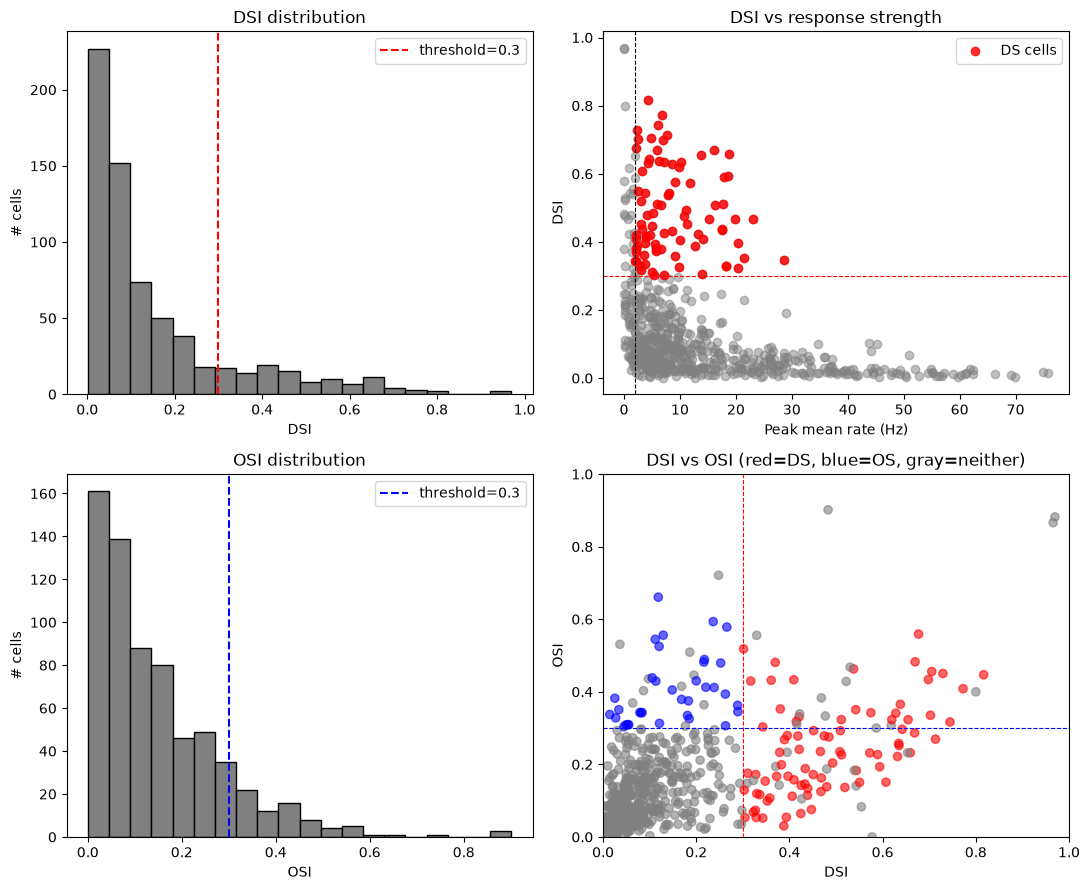

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# DSI distribution
axes[0, 0].hist(df_metrics['dsi'], bins=20, color='gray', edgecolor='black')
axes[0, 0].axvline(DSI_THRESHOLD, color='red', linestyle='--', label=f'threshold={DSI_THRESHOLD}')
axes[0, 0].set_xlabel('DSI')
axes[0, 0].set_ylabel('# cells')
axes[0, 0].set_title('DSI distribution')
axes[0, 0].legend()

# DSI vs peak rate
axes[0, 1].scatter(df_metrics['peak_rate'], df_metrics['dsi'], alpha=0.5, color='gray')
axes[0, 1].scatter(ds_cells['peak_rate'], ds_cells['dsi'], alpha=0.8, color='red', label='DS cells')
axes[0, 1].axhline(DSI_THRESHOLD, color='red', linestyle='--', linewidth=0.8)
axes[0, 1].axvline(MIN_RESPONSE_HZ, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].set_xlabel('Peak mean rate (Hz)')
axes[0, 1].set_ylabel('DSI')
axes[0, 1].set_title('DSI vs response strength')
axes[0, 1].legend()

# OSI distribution
axes[1, 0].hist(df_metrics['osi'], bins=20, color='gray', edgecolor='black')
axes[1, 0].axvline(OSI_THRESHOLD, color='blue', linestyle='--', label=f'threshold={OSI_THRESHOLD}')
axes[1, 0].set_xlabel('OSI')
axes[1, 0].set_ylabel('# cells')
axes[1, 0].set_title('OSI distribution')
axes[1, 0].legend()

# DSI vs OSI, colored by classification
colors = np.where(
    df_metrics['cell_id'].isin(ds_cells['cell_id']), 'red',
    np.where(df_metrics['cell_id'].isin(os_cells['cell_id']), 'blue', 'gray')
)
axes[1, 1].scatter(df_metrics['dsi'], df_metrics['osi'], c=colors, alpha=0.6)
axes[1, 1].axvline(DSI_THRESHOLD, color='red', linestyle='--', linewidth=0.8)
axes[1, 1].axhline(OSI_THRESHOLD, color='blue', linestyle='--', linewidth=0.8)
axes[1, 1].set_xlabel('DSI')
axes[1, 1].set_ylabel('OSI')
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title('DSI vs OSI (red=DS, blue=OS, gray=neither)')

fig.tight_layout()


## Polar tuning + raster ("smart clock") plots for individual cells

Ported and generalized from `plot_smart_clock` in the lab's existing `DS-OS.ipynb` (cell 6) to loop
over multiple cells instead of just one, and to pull its data from the DataJoint-
pipeline dataframes above (`df_trials`, `df_metrics`, `spike_times_by_cell`) instead
of the raw `_GratingDSOS.npy` file that version reads from.

For each cell: the center polar plot shows mean rate vs orientation at that cell's
best (spatialFrequency, temporalFrequency) condition, with either a red arrow (DS,
pointing at the preferred direction) or a blue axis line (OS, along the preferred
orientation) -- whichever index is stronger. The small satellite plots around the
edge are per-orientation spike rasters (one row per trial), positioned at the angle
they correspond to, with the stimulus window shaded.

--- Top 3 DS cells (by DSI) ---


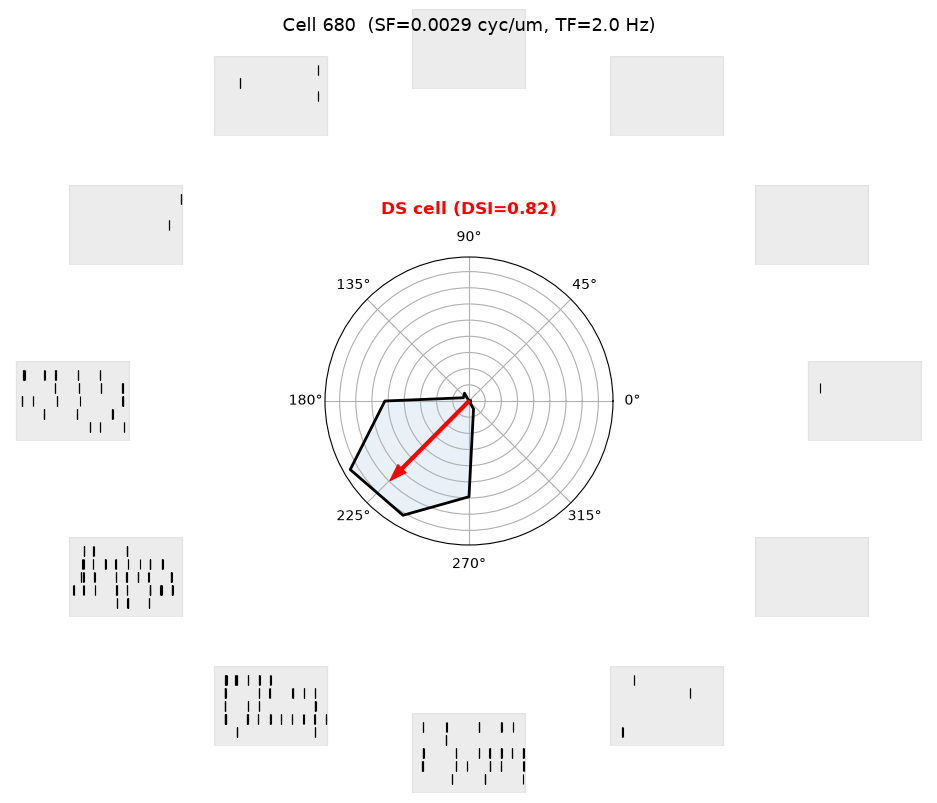

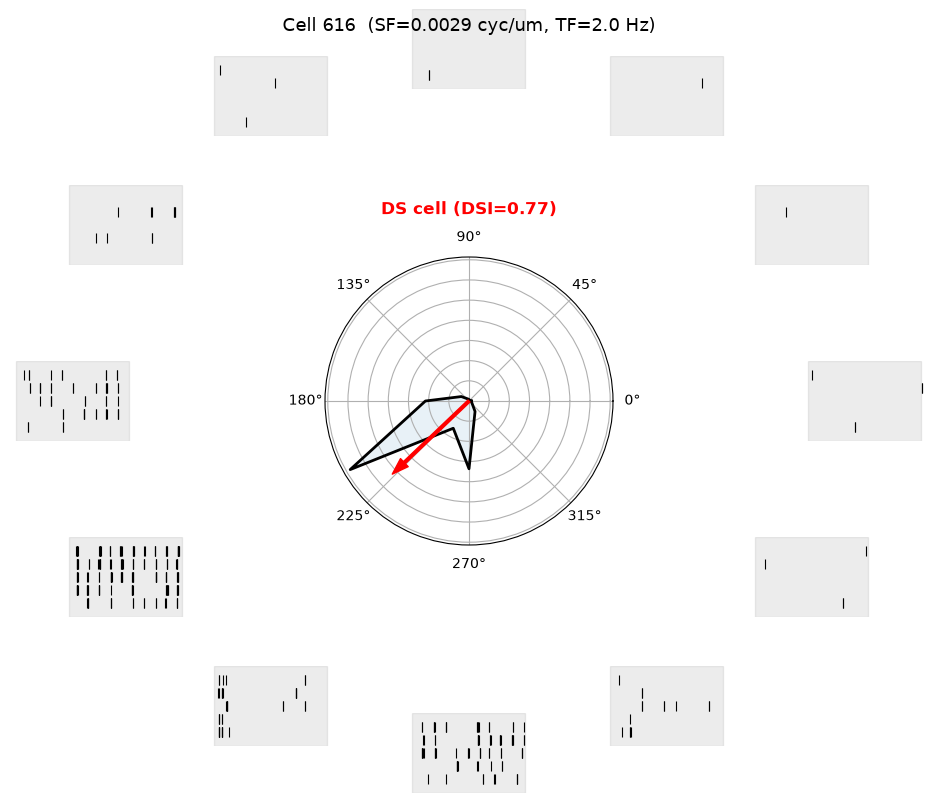

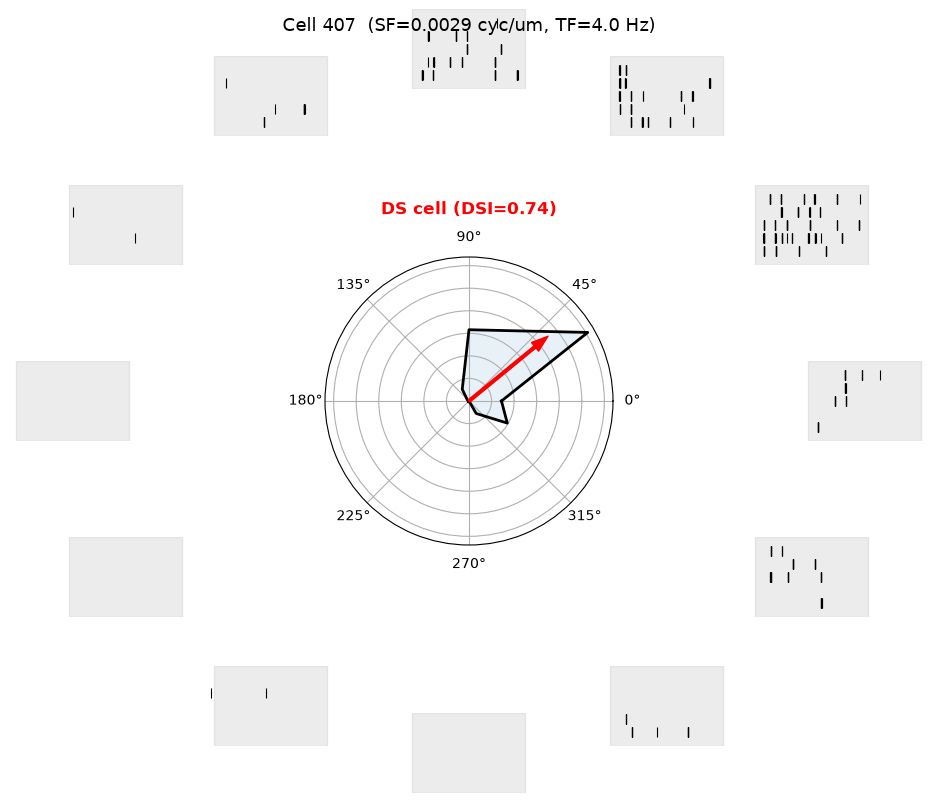

--- Top 3 OS cells (by OSI) ---


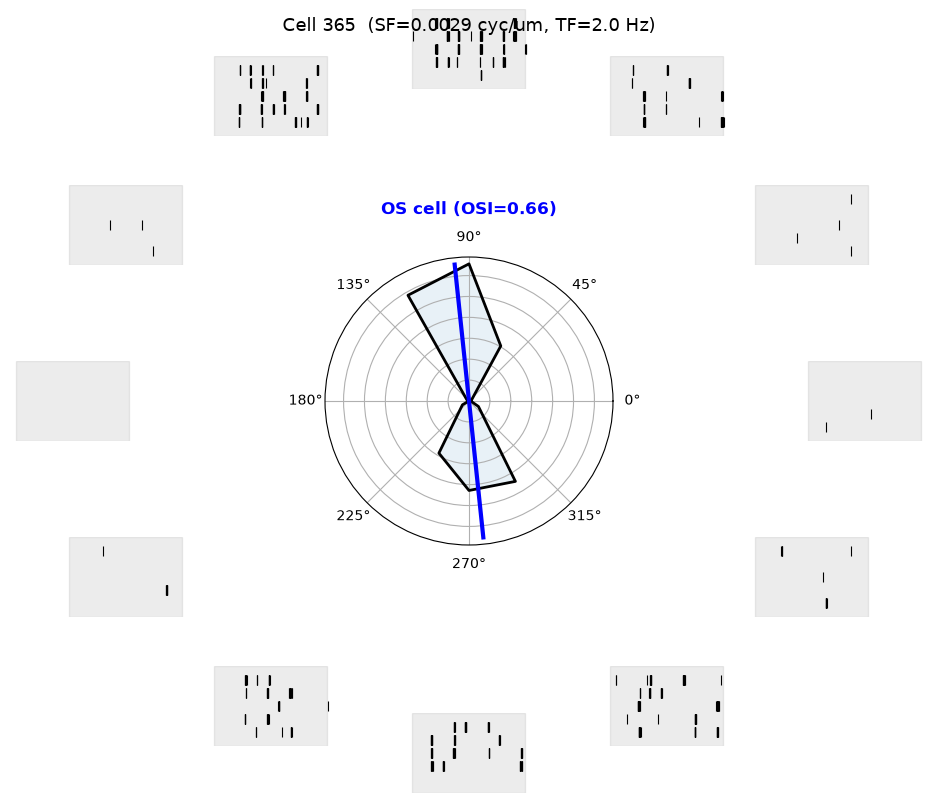

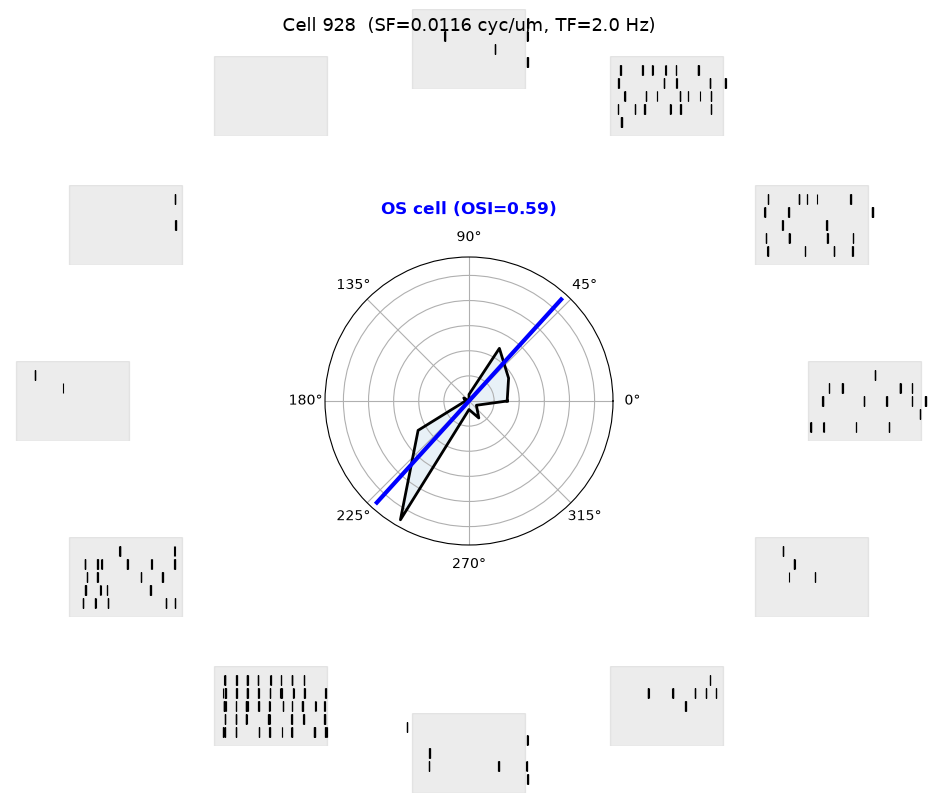

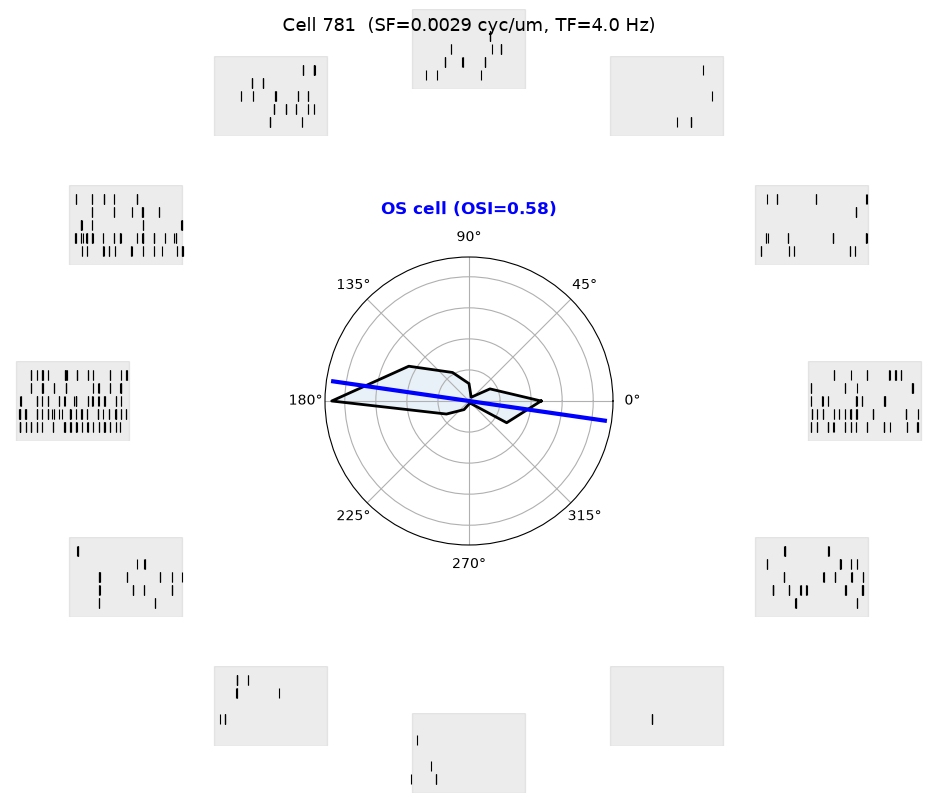

In [10]:
def plot_smart_clock(target_cell_id):
    cell_stat = df_metrics[df_metrics['cell_id'] == target_cell_id]
    if len(cell_stat) == 0:
        print(f'Cell {target_cell_id}: no metrics available, skipping.')
        return
    stat = cell_stat.iloc[0]
    target_sf, target_tf = stat['best_sf'], stat['best_tf']
    dsi_val, osi_val = stat['dsi'], stat['osi']

    condition_trials = df_trials.query(
        'cell_id == @target_cell_id and spatialFrequency == @target_sf and temporalFrequency == @target_tf'
    )
    orientations = np.sort(condition_trials['orientation'].unique())

    fig = plt.figure(figsize=(9, 8))
    ax_polar = fig.add_axes([0.32, 0.32, 0.36, 0.36], projection='polar')

    mean_rates = []
    for ori in orientations:
        ori_trials = condition_trials.query('orientation == @ori')
        mean_rates.append(ori_trials['mean_rate'].mean())

        # --- satellite raster for this orientation, placed around the clock face ---
        angle_rad = np.deg2rad(ori)
        r_plot = 0.44
        center_x = 0.5 + r_plot * np.cos(angle_rad)
        center_y = 0.5 + r_plot * np.sin(angle_rad)
        ax_sat = fig.add_axes([center_x - 0.07, center_y - 0.05, 0.14, 0.10])

        example_epoch_idx = ori_trials['epoch_index'].values[0]
        example_row = df_epochs.iloc[example_epoch_idx]
        pre_time_s = example_row['preTime'] / 1000.0
        stim_time_s = example_row['stimTime'] / 1000.0

        raster_spikes = []
        for j_epoch in ori_trials['epoch_index'].values:
            trial_spikes_ms = spike_times_by_cell.loc[target_cell_id][j_epoch]
            ts = (
                np.asarray(trial_spikes_ms) / 1000.0
                if trial_spikes_ms is not None and len(trial_spikes_ms) > 0
                else np.array([])
            )
            raster_spikes.append(ts)

        if any(len(ts) > 0 for ts in raster_spikes):
            ax_sat.eventplot(raster_spikes, colors='black', linewidths=0.8, linelengths=0.8)
        ax_sat.axvspan(pre_time_s, pre_time_s + stim_time_s, color='gray', alpha=0.15)
        ax_sat.set_xlim(0, pre_time_s + stim_time_s + 0.3)
        ax_sat.axis('off')

    angles = np.deg2rad(orientations)
    mean_rates = np.array(mean_rates)
    angles_loop = np.append(angles, angles[0])
    rates_loop = np.append(mean_rates, mean_rates[0])
    ax_polar.plot(angles_loop, rates_loop, 'k-', linewidth=2)
    ax_polar.fill(angles_loop, rates_loop, alpha=0.1)

    total_r = mean_rates.sum()
    max_r = mean_rates.max() if len(mean_rates) > 0 else 1.0
    if total_r > 0:
        vec_ds = np.sum(mean_rates * np.exp(1j * angles))
        vec_os = np.sum(mean_rates * np.exp(2j * angles))
        ds_mag = np.abs(vec_ds) / total_r
        os_mag = np.abs(vec_os) / total_r

        if os_mag > ds_mag:
            os_angle = np.angle(vec_os) / 2.0
            ax_polar.plot(
                [os_angle, os_angle + np.pi], [max_r, max_r],
                color='blue', linewidth=3,
            )
            title_color, title_text = 'blue', f'OS cell (OSI={osi_val:.2f})'
        else:
            ds_angle = np.angle(vec_ds)
            arrow_len = ds_mag * max_r
            ax_polar.annotate(
                '', xy=(ds_angle, arrow_len), xytext=(0, 0),
                arrowprops=dict(facecolor='red', edgecolor='red', width=2, headwidth=8),
            )
            title_color, title_text = 'red', f'DS cell (DSI={dsi_val:.2f})'
    else:
        title_color, title_text = 'black', 'no response'

    ax_polar.set_title(title_text, color=title_color, weight='bold', y=1.12)
    ax_polar.set_yticklabels([])
    fig.suptitle(
        f'Cell {target_cell_id}  (SF={target_sf:.4f} cyc/um, TF={target_tf} Hz)',
        fontsize=13,
    )
    plt.show()


N_TOP_EACH = 3  # how many example cells to plot per category

print(f'--- Top {N_TOP_EACH} DS cells (by DSI) ---')
for cid in ds_cells.sort_values('dsi', ascending=False)['cell_id'].values[:N_TOP_EACH]:
    plot_smart_clock(cid)

print(f'--- Top {N_TOP_EACH} OS cells (by OSI) ---')
for cid in os_cells.sort_values('osi', ascending=False)['cell_id'].values[:N_TOP_EACH]:
    plot_smart_clock(cid)
